In [3]:
# Mapeando as bases
!unzip /content/archive.zip  #

Archive:  /content/archive.zip
  inflating: olist_customers_dataset.csv  
  inflating: olist_geolocation_dataset.csv  
  inflating: olist_order_items_dataset.csv  
  inflating: olist_order_payments_dataset.csv  
  inflating: olist_order_reviews_dataset.csv  
  inflating: olist_orders_dataset.csv  
  inflating: olist_products_dataset.csv  
  inflating: olist_sellers_dataset.csv  
  inflating: product_category_name_translation.csv  


In [4]:
import pandas as pd

# Lendo o arquivo de pedidos
pedidos = pd.read_csv('olist_orders_dataset.csv')

# Mostrando as primeiras 5 linhas da tabela
pedidos.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [5]:
pedidos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [6]:
# Conta quantos pedidos existem para cada status (Entregue, Cancelado, etc)
pedidos['order_status'].value_counts()

,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


In [7]:
# 1. Carregar os pagamentos
pagamentos = pd.read_csv('olist_order_payments_dataset.csv')

# 2. Unir as duas tabelas usando o 'order_id' como ponte (a.k.a PROCV ou JOIN)
base_completa = pd.merge(pedidos, pagamentos, on='order_id')

# 3. Ver o resultado
base_completa.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,credit_card,1,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,3,voucher,1,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2,voucher,1,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,boleto,1,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,credit_card,3,179.12


In [8]:
# Qual o valor total de receita que passou por essa base?
total = base_completa['payment_value'].sum()
print(f"A receita total é: R$ {total:,.2f}")

A receita total é: R$ 16,008,872.12


In [9]:
# Agrupando a receita pelo status do pedido e somando os valores
receita_por_status = base_completa.groupby('order_status')['payment_value'].sum().reset_index()

# Organizando a lista do maior valor para o menor
receita_por_status = receita_por_status.sort_values(by='payment_value', ascending=False)

# Esse comando ajusta a visualização para mostrar em formato de moeda
pd.options.display.float_format = 'R$ {:,.2f}'.format

receita_por_status

,order_status,payment_value
3,delivered,"R$ 15,422,461.77"
6,shipped,"R$ 177,213.96"
1,canceled,"R$ 143,255.60"
7,unavailable,"R$ 126,479.51"
5,processing,"R$ 69,394.11"
4,invoiced,"R$ 69,137.99"
2,created,R$ 688.10
0,approved,R$ 241.08


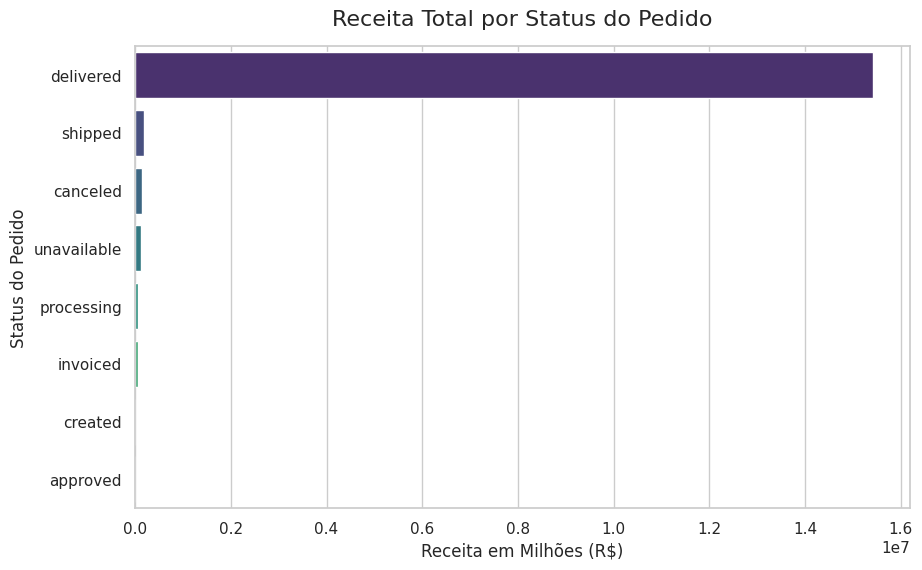

In [10]:
# Importando as bibliotecas de visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando um estilo limpo para o gráfico
sns.set_theme(style="whitegrid")

# Definindo o tamanho da "tela" do nosso gráfico (largura, altura)
plt.figure(figsize=(10, 6))

# Criando o gráfico de barras horizontais
grafico = sns.barplot(
    data=receita_por_status,
    x='payment_value',
    y='order_status',
    hue='order_status', # Colore cada barra de um jeito
    palette='viridis',  # Paleta de cores moderna
    legend=False
)

# Adicionando Títulos para facilitar a leitura
plt.title('Receita Total por Status do Pedido', fontsize=16, pad=15)
plt.xlabel('Receita em Milhões (R$)', fontsize=12)
plt.ylabel('Status do Pedido', fontsize=12)

# Comando para mostrar o gráfico final na tela
plt.show()

In [12]:
# Carregando as novas tabelas
itens = pd.read_csv('olist_order_items_dataset.csv')
produtos = pd.read_csv('olist_products_dataset.csv')

# Unindo tudo em uma base mestra
# base_completa (pedidos+pagamentos) + itens + produtos
base_mestra = pd.merge(base_completa, itens, on='order_id')
base_mestra = pd.merge(base_mestra, produtos, on='product_id')

# Transformando a coluna de data para o formato que o Python entende
base_mestra['order_purchase_timestamp'] = pd.to_datetime(base_mestra['order_purchase_timestamp'])

In [13]:
# Criando uma coluna apenas com Ano e Mês
base_mestra['ano_mes'] = base_mestra['order_purchase_timestamp'].dt.to_period('M')

# Agrupando por mês
receita_mensal = base_mestra.groupby('ano_mes')['payment_value'].sum().reset_index()
receita_mensal['ano_mes'] = receita_mensal['ano_mes'].astype(str) # Converte para texto para o gráfico

# Descobrindo o campeão
pico_vendas = receita_mensal.sort_values(by='payment_value', ascending=False).iloc[0]
print(f"O mês com maior pico foi {pico_vendas['ano_mes']} com R$ {pico_vendas['payment_value']:,.2f}")

O mês com maior pico foi 2017-11 com R$ 1,583,869.01


In [14]:
# Agrupando por categoria
categoria_campea = base_mestra.groupby('product_category_name')['payment_value'].sum().reset_index()
categoria_campea = categoria_campea.sort_values(by='payment_value', ascending=False)

# Mostrando as 5 melhores
print("Top 5 Categorias por Receita:")
print(categoria_campea.head(5))

Top 5 Categorias por Receita:
     product_category_name   payment_value
13         cama_mesa_banho R$ 1,712,553.67
11            beleza_saude R$ 1,657,373.12
44  informatica_acessorios R$ 1,585,330.45
54        moveis_decoracao R$ 1,430,176.39
66      relogios_presentes R$ 1,429,216.68


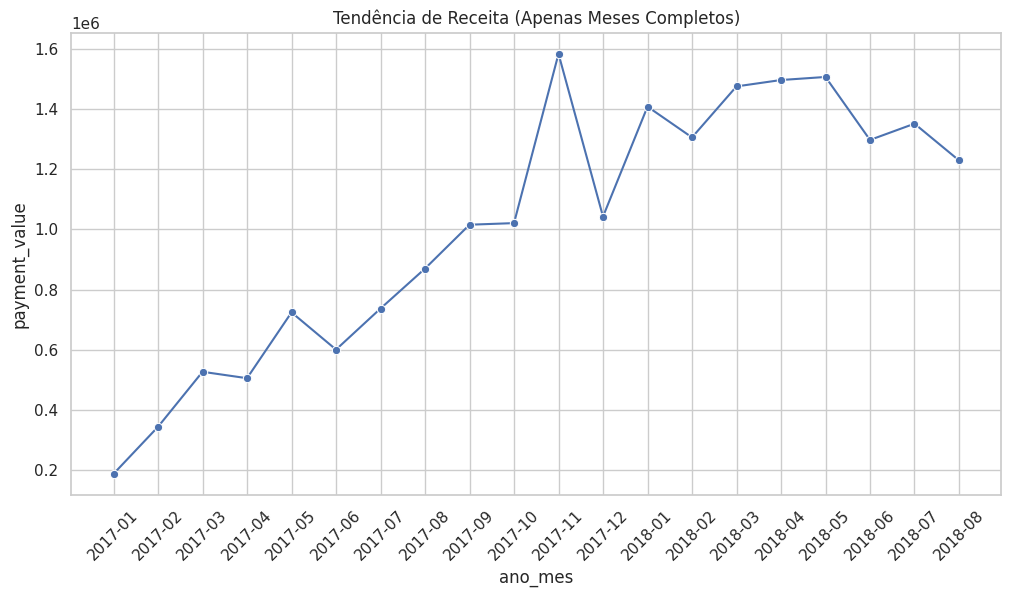

In [16]:
# Filtrando para remover meses com poucos dados (o início de 2016 e o fim de 2018)
receita_mensal_filtrada = receita_mensal[
    (receita_mensal['ano_mes'] > '2016-12') &
    (receita_mensal['ano_mes'] < '2018-09')
]

# Plotando novamente
plt.figure(figsize=(12, 6))
sns.lineplot(data=receita_mensal_filtrada, x='ano_mes', y='payment_value', marker='o')
plt.title('Tendência de Receita (Apenas Meses Completos)')
plt.xticks(rotation=45)
plt.show()